In [47]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [49]:
df = pd.read_csv('/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')

In [50]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [51]:
df.shape

(17966, 9)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [53]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [54]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

# **EDA**

<Axes: xlabel='price', ylabel='Count'>

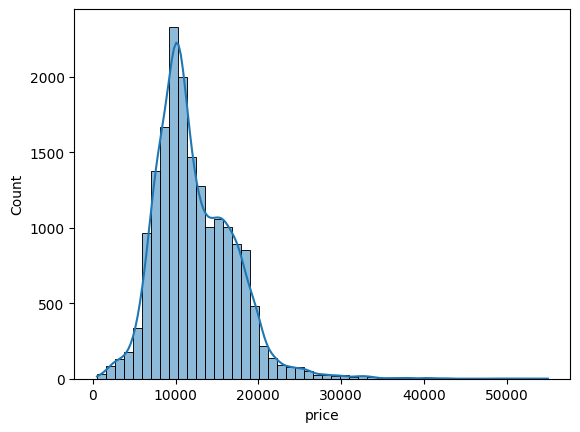

In [55]:
sns.histplot(df['price'], bins = 50, kde = True)

<Axes: >

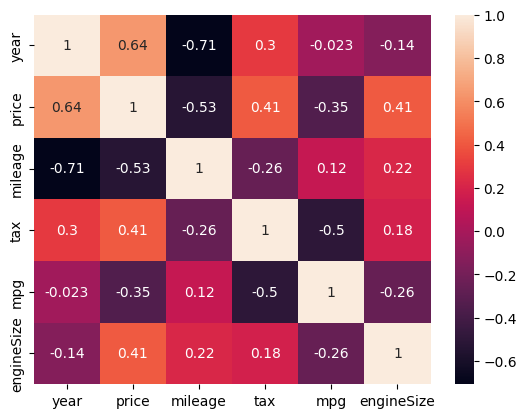

In [56]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

<Axes: xlabel='year', ylabel='price'>

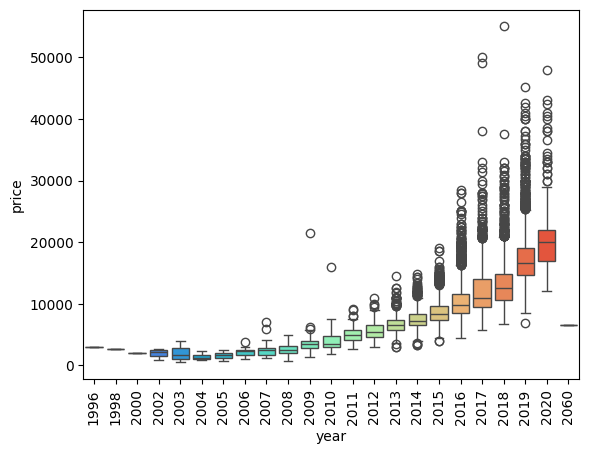

In [57]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'year', y = 'price', palette = 'rainbow')

<Axes: xlabel='mileage', ylabel='price'>

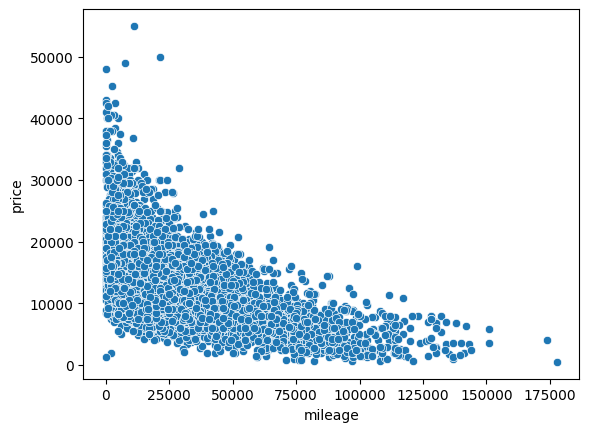

In [58]:
sns.scatterplot(data = df, x = 'mileage', y = 'price')

<Axes: xlabel='engineSize', ylabel='price'>

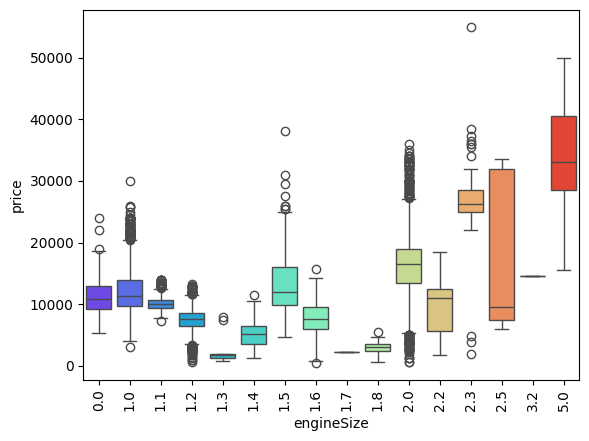

In [59]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'engineSize', y = 'price', palette = 'rainbow')

<Axes: xlabel='transmission', ylabel='price'>

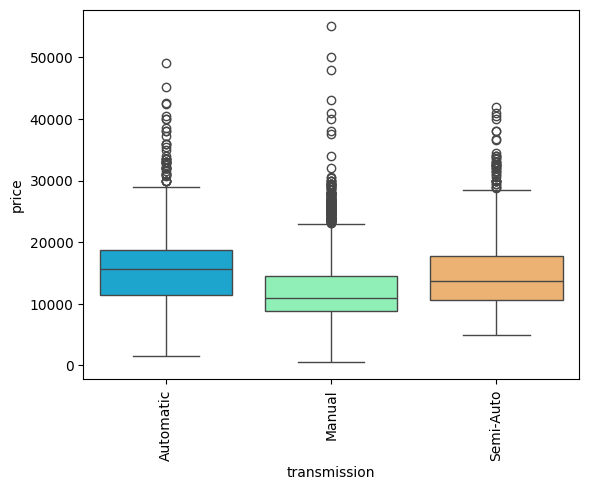

In [60]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'transmission', y = 'price', palette = 'rainbow')

<Axes: xlabel='fuelType', ylabel='price'>

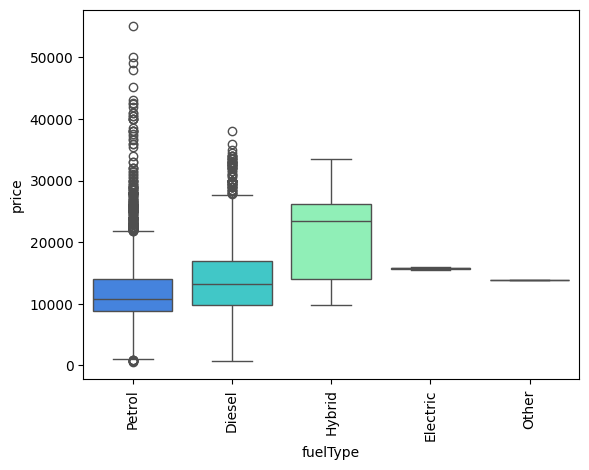

In [61]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'fuelType', y = 'price', palette = 'rainbow')

<Axes: xlabel='model', ylabel='price'>

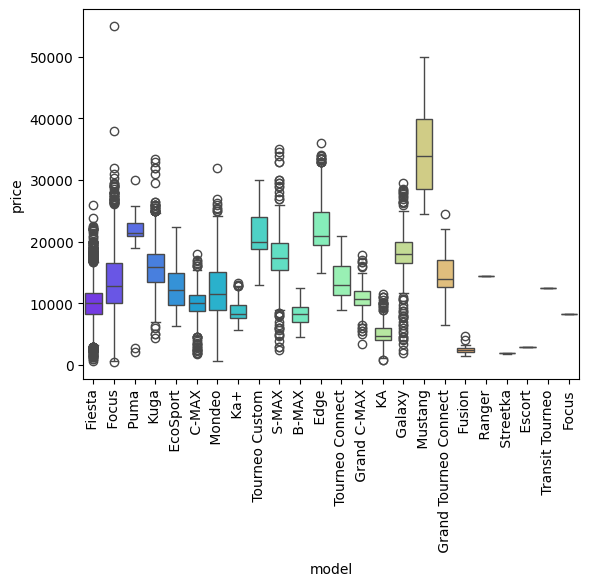

In [62]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'model', y = 'price', palette = 'rainbow')

<Axes: xlabel='mpg', ylabel='price'>

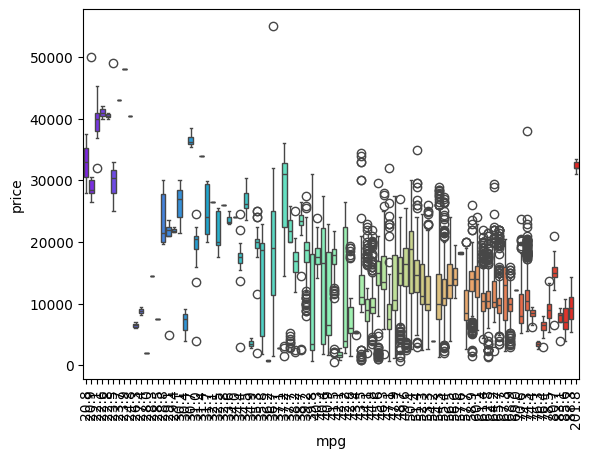

In [63]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'mpg', y = 'price', palette = 'rainbow')

<Axes: xlabel='tax', ylabel='price'>

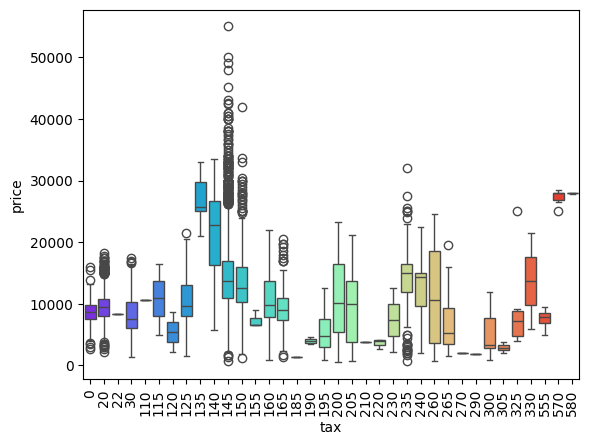

In [64]:
plt.xticks(rotation = 90)
sns.boxplot(data = df, x = 'tax', y = 'price', palette = 'rainbow')

In [65]:
X = df.drop(columns = 'price', axis = 1)
y = df['price']

In [66]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [67]:
X_one_encoded = pd.get_dummies(
    X,
    columns=['model', 'transmission', 'fuelType'], 
    drop_first=True
)

In [68]:
X_one_encoded = X_one_encoded.astype(int)

In [69]:
X_one_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [70]:
from sklearn.preprocessing import LabelEncoder

columns = ['model', 'transmission', 'fuelType']

Xlabels = X.copy()
label_encoders = {} 

for col in columns: 
    le = LabelEncoder()
    Xlabels[col] = le.fit_transform(Xlabels[col].astype(str))  # Convert to string in case of nulls
    label_encoders[col] = le

In [71]:
Xlabels

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [72]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X_one_encoded[numerical_cols] = scaler.fit_transform(X_one_encoded[numerical_cols])

In [73]:
X_one_encoded.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [74]:
Xlabels.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [75]:
Xlabels[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scalar.fit_transform(Xlabels[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

NameError: name 'scalar' is not defined

In [ ]:
Xlabels

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encoded, y, test_size=0.33, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(Xlabels, y, test_size=0.33, random_state=42)

In [ ]:
model2 = LinearRegression()
model2.fit(X_train,y_train)

In [ ]:
y_pred = model2.predict(X_test)

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
r2 = r2_score(y_test,y_pred)
r2

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)